Time Series for Malaysia Population Data without Considering External Factors

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))

from paths import DATA_FILE

population_data = pd.read_csv(DATA_FILE)
population_data.head()

,state,date,sex,age,ethnicity,population
0,Johor,1970-01-01,both,overall,overall,1325.6
1,Johor,1970-01-01,both,0-4,overall,210.1
2,Johor,1970-01-01,both,5-9,overall,215.7
3,Johor,1970-01-01,both,10-14,overall,192.2
4,Johor,1970-01-01,both,15-19,overall,152.8


In [4]:
population_data["year"] = pd.to_datetime(population_data["date"]).dt.year
population_data.head()

,state,date,sex,age,ethnicity,population,year
0,Johor,1970-01-01,both,overall,overall,1325.6,1970
1,Johor,1970-01-01,both,0-4,overall,210.1,1970
2,Johor,1970-01-01,both,5-9,overall,215.7,1970
3,Johor,1970-01-01,both,10-14,overall,192.2,1970
4,Johor,1970-01-01,both,15-19,overall,152.8,1970


In [5]:
population_data = population_data[(population_data["age"] == "overall") &
                                          (population_data["ethnicity"] == "overall") &
                                          (population_data["sex"] == "both")]
population_data.head()

,state,date,sex,age,ethnicity,population,year
0,Johor,1970-01-01,both,overall,overall,1325.6,1970
48,Johor,1971-01-01,both,overall,overall,1355.4,1971
96,Johor,1972-01-01,both,overall,overall,1385.3,1972
144,Johor,1973-01-01,both,overall,overall,1414.5,1973
192,Johor,1974-01-01,both,overall,overall,1444.4,1974


In [6]:
grouped = population_data.pivot_table("population", index = "state",
                                         columns = ["year"], aggfunc="sum")
grouped = grouped.T
grouped

state,Johor,Kedah,Kelantan,Melaka,Negeri Sembilan,Pahang,Perak,Perlis,Pulau Pinang,Sabah,Sarawak,Selangor,Terengganu,W.P. Kuala Lumpur,W.P. Labuan,W.P. Putrajaya
year,,,,,,,,,,,,,,,,
1970,1325.6,989.5,707.3,419.4,500.4,523.8,1631.5,125.5,808.6,698.1,1037.0,1696.4,418.8,NaN,NaN,NaN
1971,1355.4,1003.9,723.6,424.9,508.2,548.4,1650.9,127.4,823.7,728.1,1065.2,1770.9,429.0,NaN,NaN,NaN
1972,1385.3,1017.3,741.1,429.9,515.9,574.0,1669.3,129.7,838.9,759.5,1094.3,1846.7,439.5,NaN,NaN,NaN
1973,1414.5,1029.0,759.5,434.2,522.8,599.3,1686.0,131.7,852.9,792.4,1124.1,1922.4,451.0,NaN,NaN,NaN
1974,1444.4,1041.1,776.8,438.1,530.0,626.0,1702.7,133.8,866.7,826.9,1154.7,1997.9,462.0,NaN,NaN,NaN
1975,1477.0,1054.9,796.1,443.1,537.6,653.4,1720.9,136.2,881.7,863.0,1186.2,2075.3,474.9,NaN,NaN,NaN
1976,1508.4,1065.4,814.1,447.3,544.3,680.4,1736.7,138.3,896.4,898.1,1217.5,2154.3,486.9,NaN,NaN,NaN
1977,1541.9,1079.8,834.2,452.1,551.8,709.5,1755.6,141.0,912.2,934.8,1249.6,2237.7,500.9,NaN,NaN,NaN
1978,1573.4,1090.9,852.5,456.2,558.7,738.2,1771.5,143.2,925.7,973.2,1282.5,2320.9,513.4,NaN,NaN,NaN


In [7]:
grouped = grouped.fillna(0)
grouped["Malaysia"] = grouped.sum(axis=1)
grouped

state,Johor,Kedah,Kelantan,Melaka,Negeri Sembilan,Pahang,Perak,Perlis,Pulau Pinang,Sabah,Sarawak,Selangor,Terengganu,W.P. Kuala Lumpur,W.P. Labuan,W.P. Putrajaya,Malaysia
year,,,,,,,,,,,,,,,,,
1970,1325.6,989.5,707.3,419.4,500.4,523.8,1631.5,125.5,808.6,698.1,1037.0,1696.4,418.8,0.0,0.0,0.0,10881.9
1971,1355.4,1003.9,723.6,424.9,508.2,548.4,1650.9,127.4,823.7,728.1,1065.2,1770.9,429.0,0.0,0.0,0.0,11159.6
1972,1385.3,1017.3,741.1,429.9,515.9,574.0,1669.3,129.7,838.9,759.5,1094.3,1846.7,439.5,0.0,0.0,0.0,11441.4
1973,1414.5,1029.0,759.5,434.2,522.8,599.3,1686.0,131.7,852.9,792.4,1124.1,1922.4,451.0,0.0,0.0,0.0,11719.8
1974,1444.4,1041.1,776.8,438.1,530.0,626.0,1702.7,133.8,866.7,826.9,1154.7,1997.9,462.0,0.0,0.0,0.0,12001.1
1975,1477.0,1054.9,796.1,443.1,537.6,653.4,1720.9,136.2,881.7,863.0,1186.2,2075.3,474.9,0.0,0.0,0.0,12300.3
1976,1508.4,1065.4,814.1,447.3,544.3,680.4,1736.7,138.3,896.4,898.1,1217.5,2154.3,486.9,0.0,0.0,0.0,12588.1
1977,1541.9,1079.8,834.2,452.1,551.8,709.5,1755.6,141.0,912.2,934.8,1249.6,2237.7,500.9,0.0,0.0,0.0,12901.1
1978,1573.4,1090.9,852.5,456.2,558.7,738.2,1771.5,143.2,925.7,973.2,1282.5,2320.9,513.4,0.0,0.0,0.0,13200.3


In [8]:
malaysia_data = grouped["Malaysia"]
malaysia_data

year
1970    10881.9
1971    11159.6
1972    11441.4
1973    11719.8
1974    12001.1
1975    12300.3
1976    12588.1
1977    12901.1
1978    13200.3
1979    13518.4
1980    13879.2
1981    14256.9
1982    14651.1
1983    15048.2
1984    15450.4
1985    15882.9
1986    16329.4
1987    16773.4
1988    17219.2
1989    17662.0
1990    18102.5
1991    18547.2
1992    19067.5
1993    19601.6
1994    20141.6
1995    20681.7
1996    21222.5
1997    21769.2
1998    22333.5
1999    22909.4
2000    23494.9
2001    24030.6
2002    24542.7
2003    25038.0
2004    25541.3
2005    26045.5
2006    26549.9
2007    27058.3
2008    27567.7
2009    28081.6
2010    28588.8
2011    29062.1
2012    29509.9
2013    30213.8
2014    30708.6
2015    31186.1
2016    31633.4
2017    32022.5
2018    32382.3
2019    32522.8
2020    32447.3
2021    32576.4
2022    32698.3
2023    33401.8
2024    34052.3
2025    34231.8
Name: Malaysia, dtype: float64

From plot, generally, population is increasing

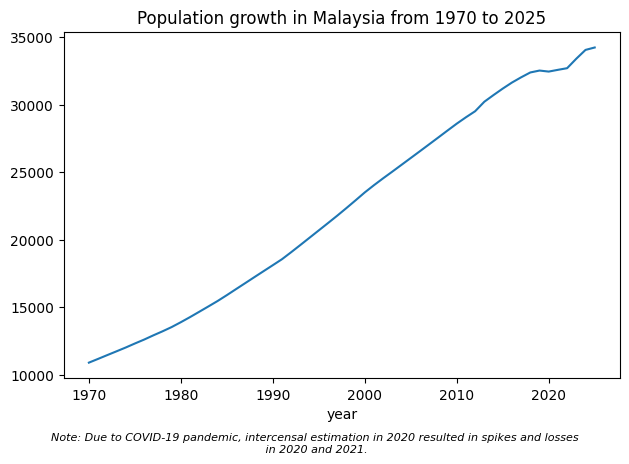

In [9]:
ax = malaysia_data.plot(title= "Population growth in Malaysia from 1970 to 2025")
plt.figtext(
    0.5, 0.05, 
    "Note: Due to COVID-19 pandemic, intercensal estimation in 2020 resulted in spikes and losses\n in 2020 and 2021.",
    wrap=True, ha='center', fontsize=8, style='italic'
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Extra space for footnote

plt.show()

Stationarity Test using Augmented Dicket-Fulley test

We would want to reject non-stationarity hypothesis after differencing. But, first confirm that population data is generally non-stationary.

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(malaysia_data)
print(f'Augmneted Dickey_fuller Statistic: {result[0]}')
print(f'p-value: {result[1]}')

Augmneted Dickey_fuller Statistic: -3.809346281851878
p-value: 0.0028131248574347913


Well, it seems like the data is stationary as p-value is less than 0.05. But, double check with rolling mean and standard variance

<Axes: xlabel='year'>

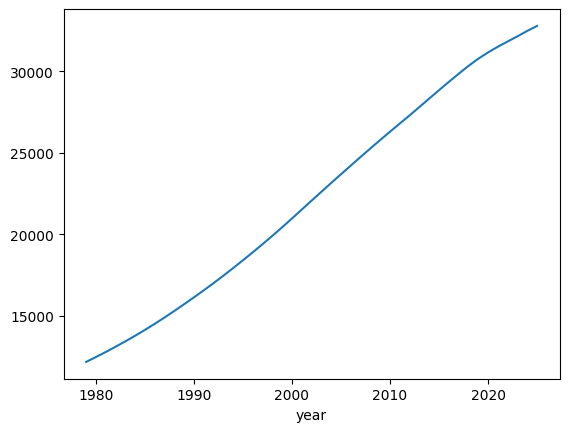

In [11]:
malaysia_data.rolling(10).mean().plot()

<Axes: xlabel='year'>

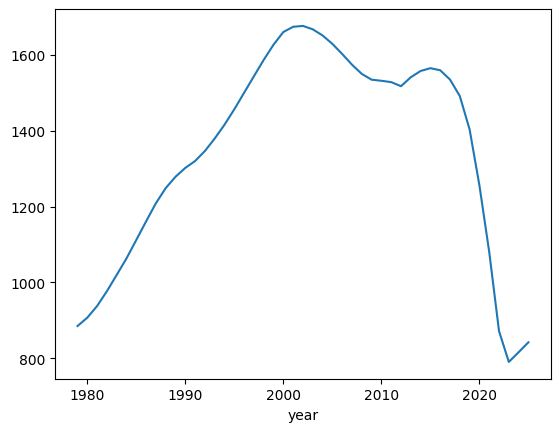

In [12]:
malaysia_data.rolling(10).std().plot()

The rolling mean and standard deviation curves suggest that although ADF test suggests stationarity, rolling mean plot that trends upwards and rolling standard deviation plot that almost have inverted U-shape suggests that ADF falsely rejects non-stationarity

We can immediately deduce that Autoregressive Integrated Moving Average (ARIMA) model should not use d = 0

Diffencing data and test again for stationarity

In [13]:
malaysia_diff_data = malaysia_data.diff().dropna()
malaysia_diff_data

year
1971    277.7
1972    281.8
1973    278.4
1974    281.3
1975    299.2
1976    287.8
1977    313.0
1978    299.2
1979    318.1
1980    360.8
1981    377.7
1982    394.2
1983    397.1
1984    402.2
1985    432.5
1986    446.5
1987    444.0
1988    445.8
1989    442.8
1990    440.5
1991    444.7
1992    520.3
1993    534.1
1994    540.0
1995    540.1
1996    540.8
1997    546.7
1998    564.3
1999    575.9
2000    585.5
2001    535.7
2002    512.1
2003    495.3
2004    503.3
2005    504.2
2006    504.4
2007    508.4
2008    509.4
2009    513.9
2010    507.2
2011    473.3
2012    447.8
2013    703.9
2014    494.8
2015    477.5
2016    447.3
2017    389.1
2018    359.8
2019    140.5
2020    -75.5
2021    129.1
2022    121.9
2023    703.5
2024    650.5
2025    179.5
Name: Malaysia, dtype: float64

<Axes: xlabel='year'>

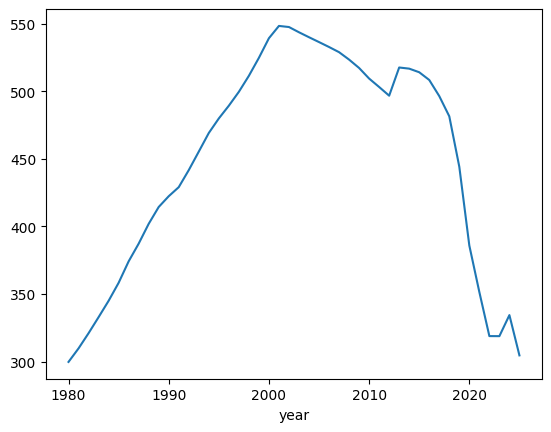

In [14]:
malaysia_diff_data.rolling(10).mean().plot()

<Axes: xlabel='year'>

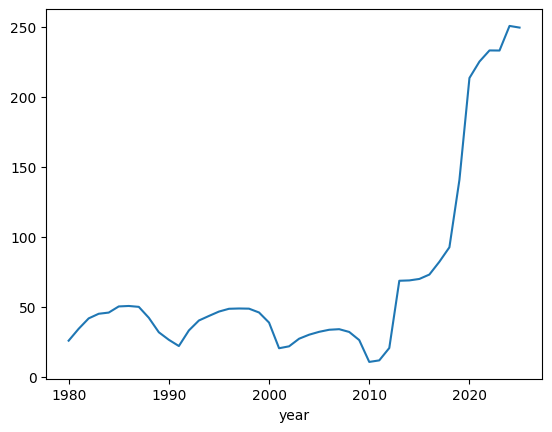

In [15]:
malaysia_diff_data.rolling(10).std().plot()

In [16]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(malaysia_diff_data)
print(f'Augmneted Dickey_fuller Statistic: {result[0]}')
print(f'p-value: {result[1]}')

Augmneted Dickey_fuller Statistic: -1.272088164874717
p-value: 0.6418433290330038


It seems like the population growth rate also has a trend

Try second differencing of data

In [17]:
malaysia_diff2_data = malaysia_data.diff().diff().dropna()
malaysia_diff2_data

year
1972      4.1
1973     -3.4
1974      2.9
1975     17.9
1976    -11.4
1977     25.2
1978    -13.8
1979     18.9
1980     42.7
1981     16.9
1982     16.5
1983      2.9
1984      5.1
1985     30.3
1986     14.0
1987     -2.5
1988      1.8
1989     -3.0
1990     -2.3
1991      4.2
1992     75.6
1993     13.8
1994      5.9
1995      0.1
1996      0.7
1997      5.9
1998     17.6
1999     11.6
2000      9.6
2001    -49.8
2002    -23.6
2003    -16.8
2004      8.0
2005      0.9
2006      0.2
2007      4.0
2008      1.0
2009      4.5
2010     -6.7
2011    -33.9
2012    -25.5
2013    256.1
2014   -209.1
2015    -17.3
2016    -30.2
2017    -58.2
2018    -29.3
2019   -219.3
2020   -216.0
2021    204.6
2022     -7.2
2023    581.6
2024    -53.0
2025   -471.0
Name: Malaysia, dtype: float64

<Axes: xlabel='year'>

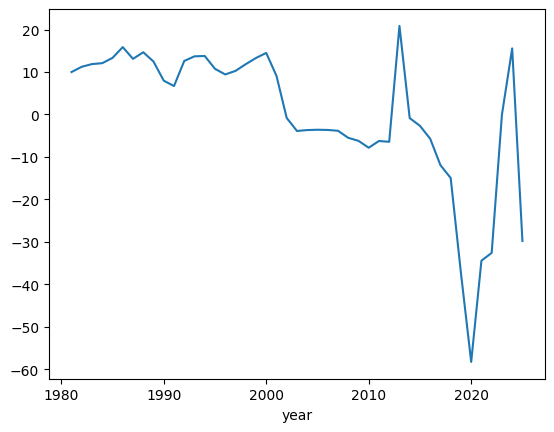

In [18]:
malaysia_diff2_data.rolling(10).mean().plot()

<Axes: xlabel='year'>

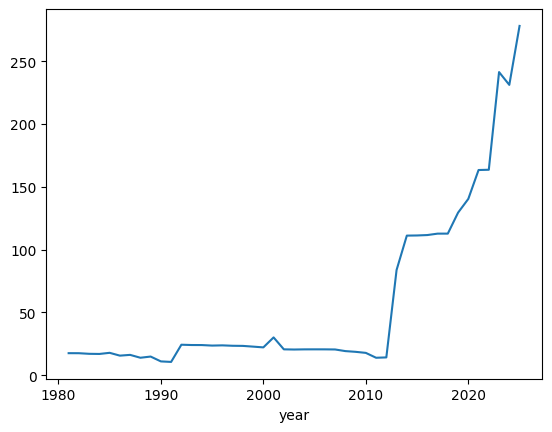

In [19]:
malaysia_diff2_data.rolling(10).std().plot()

In [20]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(malaysia_diff2_data)
print(f'Augmneted Dickey_fuller Statistic: {result[0]}')
print(f'p-value: {result[1]}')

Augmneted Dickey_fuller Statistic: -1.2558846643816342
p-value: 0.6491058911054858


Let's go for third differntiation

In [21]:
malaysia_diff3_data = malaysia_diff_data.diff().diff().diff().dropna()
malaysia_diff3_data

year
1974      13.8
1975       8.7
1976     -44.3
1977      65.9
1978     -75.6
1979      71.7
1980      -8.9
1981     -49.6
1982      25.4
1983     -13.2
1984      15.8
1985      23.0
1986     -41.5
1987      -0.2
1988      20.8
1989      -9.1
1990       5.5
1991       5.8
1992      64.9
1993    -133.2
1994      53.9
1995       2.1
1996       6.4
1997       4.6
1998       6.5
1999     -17.7
2000       4.0
2001     -57.4
2002      85.6
2003     -19.4
2004      18.0
2005     -31.9
2006       6.4
2007       4.5
2008      -6.8
2009       6.5
2010     -14.7
2011     -16.0
2012      35.6
2013     273.2
2014    -746.8
2015     657.0
2016    -204.7
2017     -15.1
2018      56.9
2019    -218.9
2020     193.3
2021     417.3
2022    -632.4
2023     800.6
2024   -1223.4
2025     216.6
Name: Malaysia, dtype: float64

<Axes: xlabel='year'>

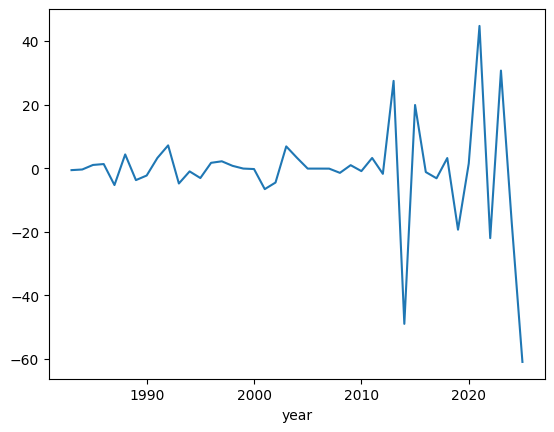

In [22]:
malaysia_diff3_data.rolling(10).mean().plot()

<Axes: xlabel='year'>

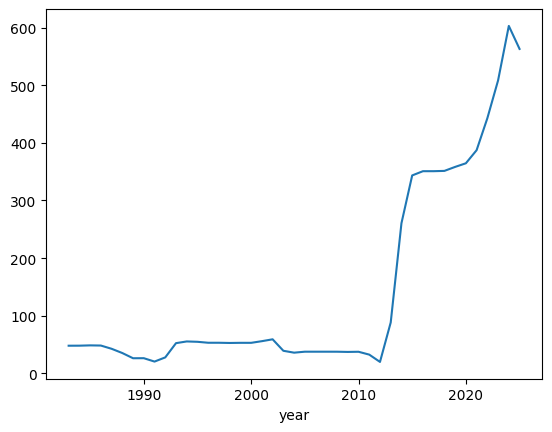

In [23]:
malaysia_diff3_data.rolling(10).std().plot()

In [24]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(malaysia_diff3_data)
print(f'Augmneted Dickey_fuller Statistic: {result[0]}')
print(f'p-value: {result[1]}')

Augmneted Dickey_fuller Statistic: -2.8436659993524147
p-value: 0.052302013027573806


A fourth differencing finally rejects ADF test, but rolling standard deviation plot strongly suggests that population data has structural breaks, rendering it useless

In [25]:
malaysia_diff4_data = malaysia_diff_data.diff().diff().diff().diff().dropna()
malaysia_diff4_data

year
1975      -5.1
1976     -53.0
1977     110.2
1978    -141.5
1979     147.3
1980     -80.6
1981     -40.7
1982      75.0
1983     -38.6
1984      29.0
1985       7.2
1986     -64.5
1987      41.3
1988      21.0
1989     -29.9
1990      14.6
1991       0.3
1992      59.1
1993    -198.1
1994     187.1
1995     -51.8
1996       4.3
1997      -1.8
1998       1.9
1999     -24.2
2000      21.7
2001     -61.4
2002     143.0
2003    -105.0
2004      37.4
2005     -49.9
2006      38.3
2007      -1.9
2008     -11.3
2009      13.3
2010     -21.2
2011      -1.3
2012      51.6
2013     237.6
2014   -1020.0
2015    1403.8
2016    -861.7
2017     189.6
2018      72.0
2019    -275.8
2020     412.2
2021     224.0
2022   -1049.7
2023    1433.0
2024   -2024.0
2025    1440.0
Name: Malaysia, dtype: float64

<Axes: xlabel='year'>

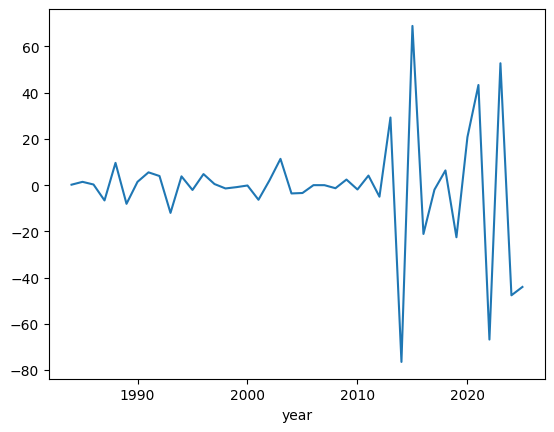

In [26]:
malaysia_diff4_data.rolling(10).mean().plot()

<Axes: xlabel='year'>

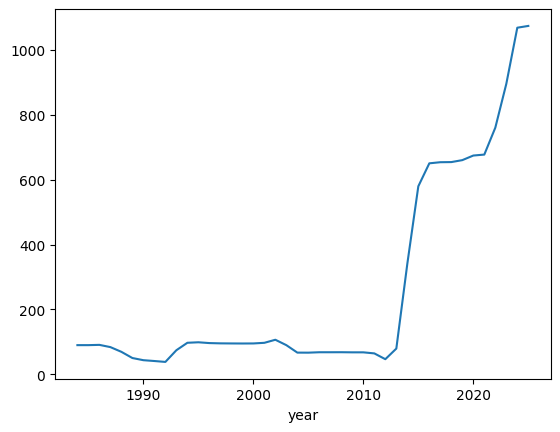

In [27]:
malaysia_diff4_data.rolling(10).std().plot()

In [28]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(malaysia_diff4_data)
print(f'Augmneted Dickey_fuller Statistic: {result[0]}')
print(f'p-value: {result[1]}')

Augmneted Dickey_fuller Statistic: -5.961198239696344
p-value: 2.037117892488146e-07


Well, due to structural changes, we should test Phillips-Perron test (PP), Zivot Andrews test (ZA), and optionally, Leybourne-McCabe test (LM)

ARIMA with d = 1 may be used, but Error, Trend, Seasonality exponential smoothing (ETS) is better